In [18]:
!pip install -q imbalanced-learn scikit-learn pandas requests

import pandas as pd
import os
import requests
import io
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive


drive.mount('/content/drive', force_remount=True)
url_download = f'https://drive.google.com/uc?export=download&id={'1qUugvPtq553XDjHepQR4wFxkCErnAUyr'}'

Mounted at /content/drive


In [13]:
def processar_dados(url):

    # Download e leitura
    response = requests.get(url)
    response.raise_for_status()
    df = pd.read_csv(io.StringIO(response.text))
    print(f"[OK] Dados lidos! {df.shape[0]} linhas encontradas.")

    # Separando os dados com estratificação (stratify)- 20% para teste
    X = df.drop(columns=['Potability'])
    y = df['Potability']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Criando o pipeline (Imputer + Scaler)
    pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    # Aplicando as transformações (fit_transform no treino, só transform no teste)
    X_train_processed = pipeline.fit_transform(X_train)
    X_test_processed = pipeline.transform(X_test)

    # Voltando pra DataFrame
    colunas = X.columns
    X_train_df = pd.DataFrame(X_train_processed, columns=colunas)
    X_test_df = pd.DataFrame(X_test_processed, columns=colunas)

    # Balanceando o treino com SMOTE
    smote = SMOTE(random_state=42)
    X_train_bal, y_train_bal = smote.fit_resample(X_train_df, y_train)

    return X_train_bal, X_test_df, y_train_bal, y_test

In [14]:
X_train, X_test, y_train, y_test = processar_dados(url_download)

Baixando e processando os dados direto do link...
[OK] Dados lidos com sucesso! 3276 linhas encontradas.


In [15]:
caminho_drive = '/content/drive/MyDrive/Topicos_Trabalho_Final'
pasta_destino = caminho_drive if os.path.exists(caminho_drive) else '/content'

In [16]:
# Salvando os arquivos
X_train.to_csv(os.path.join(pasta_destino, 'X_treino.csv'), index=False)
X_test.to_csv(os.path.join(pasta_destino, 'X_teste.csv'), index=False)
y_train.to_csv(os.path.join(pasta_destino, 'y_treino.csv'), index=False)
y_test.to_csv(os.path.join(pasta_destino, 'y_teste.csv'), index=False)


DISTRIBUIÇÃO NO TREINO APÓS SMOTE
Potability
0    1598
1    1598
Name: count, dtype: int64


/tmp/ipykernel_22338/816919633.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='viridis')


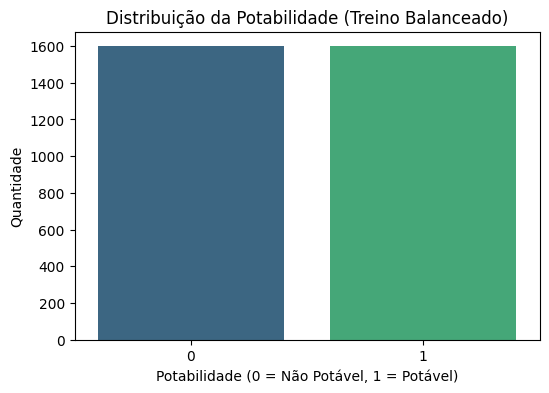

In [17]:
print("\n" + "="*50)
print("DISTRIBUIÇÃO NO TREINO APÓS SMOTE")
print("="*50)
print(y_train.value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x=y_train, palette='viridis')
plt.title('Distribuição da Potabilidade (Treino Balanceado)')
plt.xlabel('Potabilidade (0 = Não Potável, 1 = Potável)')
plt.ylabel('Quantidade')
plt.show()

**Conclusão do Pré-processamento**

Prevenção de Data Leakage: Separamos o dataset em treino (80%) e teste (20%).

Tratamento e Padronização: Preenchemos os nulos usando a mediana do treino e aplicamos o StandardScaler para colocar todas as variáveis na mesma escala matemática.

Balanceamento de Classes: Rodamos o SMOTE exclusivamente no treino, igualando a proporção da potabilidade (1598 amostras de cada lado). O conjunto de teste foi mantido para refletir o cenário real.

Próximos Passos: Geramos os 4 arquivos CSV finais. A equipe de modelagem já pode carregar esses dados limpos e utilizar o .fit() diretamente para ajustar os algoritmos, preferencialmente utilizando validação cruzada.